In [1]:
from pathlib import Path
import pandas as pd

from datasets import load_dataset

dataset = load_dataset(
    "renumics/esc50",
    split="train"
)

selected_classes = [
    "dog",
    "cat",
    "rain",
    "clapping",
    "footsteps",
    "car_horn",
    "siren",
    "thunderstorm",
    "keyboard_typing",
    "church_bells"
]

selected_ids = [
    dataset.features["label"].str2int(label)
    for label in selected_classes
]

selected_indices = [
    i for i, label_id in enumerate(dataset["label"])
    if label_id in selected_ids
]

small_dataset = dataset.select(selected_indices)

small_dataset = small_dataset.shuffle(seed=42)
small_dataset = small_dataset.select(
    range(min(250, len(small_dataset)))
)

print("Dataset size:", len(small_dataset))

e:\Audio-Environmental-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset size: 250


In [3]:
from pathlib import Path

metadata_path = Path("../ESC-50-master/meta/esc50.csv")

print(metadata_path.exists())

True


In [4]:
import pandas as pd

metadata = pd.read_csv(metadata_path)

metadata.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [5]:
raw_dir = Path("../data/raw")

wav_files = [file.name for file in raw_dir.glob("*.wav")]

labels_df = metadata[
    metadata["filename"].isin(wav_files)
][["filename", "category"]].copy()

labels_df = labels_df.rename(
    columns={"category": "actual_label"}
)

print("Number of files:", len(labels_df))

labels_df.head()

Number of files: 250


,filename,actual_label
0,1-100032-A-0.wav,dog
5,1-101296-B-19.wav,thunderstorm
11,1-104089-A-22.wav,clapping
15,1-110537-A-22.wav,clapping
16,1-115521-A-19.wav,thunderstorm


In [6]:
def get_prediction(audio_path):
    audio, sample_rate = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    probability, index = torch.max(
        probabilities,
        dim=-1
    )

    predicted_label = model.config.id2label[index.item()]
    confidence = probability.item() * 100

    return predicted_label, confidence

In [8]:
import torch
import librosa
from pathlib import Path
import pandas as pd

print("Libraries loaded!")

Libraries loaded!


In [10]:
import torch
import librosa

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification
)

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME
)

model.eval()

print("Model loaded successfully!")

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 717.95it/s]

Model loaded successfully!


In [11]:
from pathlib import Path
import pandas as pd

raw_dir = Path("../data/raw")

results = []

for _, row in labels_df.head(10).iterrows():

    audio_path = raw_dir / row["filename"]

    predicted_label, confidence = get_prediction(audio_path)

    results.append({
        "filename": row["filename"],
        "actual_label": row["actual_label"],
        "predicted_label": predicted_label,
        "confidence": confidence
    })

results_df = pd.DataFrame(results)

results_df

,filename,actual_label,predicted_label,confidence
0,1-100032-A-0.wav,dog,Bark,18.755327
1,1-101296-B-19.wav,thunderstorm,Thunder,54.907465
2,1-104089-A-22.wav,clapping,Clapping,79.103500
3,1-110537-A-22.wav,clapping,Applause,90.144509
4,1-115521-A-19.wav,thunderstorm,Thunder,48.752213
5,1-115921-A-22.wav,clapping,Clapping,43.916723
6,1-13571-A-46.wav,church_bells,Church bell,71.364266
7,1-155858-D-25.wav,footsteps,Clapping,19.011675
8,1-155858-E-25.wav,footsteps,Fireworks,56.323344
9,1-155858-F-25.wav,footsteps,"Walk, footsteps",46.649706


In [12]:
results_df.to_csv(
    "../results/audio_predictions.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [13]:
results_df

,filename,actual_label,predicted_label,confidence
0,1-100032-A-0.wav,dog,Bark,18.755327
1,1-101296-B-19.wav,thunderstorm,Thunder,54.907465
2,1-104089-A-22.wav,clapping,Clapping,79.103500
3,1-110537-A-22.wav,clapping,Applause,90.144509
4,1-115521-A-19.wav,thunderstorm,Thunder,48.752213
5,1-115921-A-22.wav,clapping,Clapping,43.916723
6,1-13571-A-46.wav,church_bells,Church bell,71.364266
7,1-155858-D-25.wav,footsteps,Clapping,19.011675
8,1-155858-E-25.wav,footsteps,Fireworks,56.323344
9,1-155858-F-25.wav,footsteps,"Walk, footsteps",46.649706


In [14]:
results_df["confidence"] = results_df["confidence"].round(2)

results_df

,filename,actual_label,predicted_label,confidence
0,1-100032-A-0.wav,dog,Bark,18.76
1,1-101296-B-19.wav,thunderstorm,Thunder,54.91
2,1-104089-A-22.wav,clapping,Clapping,79.10
3,1-110537-A-22.wav,clapping,Applause,90.14
4,1-115521-A-19.wav,thunderstorm,Thunder,48.75
5,1-115921-A-22.wav,clapping,Clapping,43.92
6,1-13571-A-46.wav,church_bells,Church bell,71.36
7,1-155858-D-25.wav,footsteps,Clapping,19.01
8,1-155858-E-25.wav,footsteps,Fireworks,56.32
9,1-155858-F-25.wav,footsteps,"Walk, footsteps",46.65


In [15]:
results_df.sort_values(
    "confidence",
    ascending=False
)

,filename,actual_label,predicted_label,confidence
3,1-110537-A-22.wav,clapping,Applause,90.14
2,1-104089-A-22.wav,clapping,Clapping,79.10
6,1-13571-A-46.wav,church_bells,Church bell,71.36
8,1-155858-E-25.wav,footsteps,Fireworks,56.32
1,1-101296-B-19.wav,thunderstorm,Thunder,54.91
4,1-115521-A-19.wav,thunderstorm,Thunder,48.75
9,1-155858-F-25.wav,footsteps,"Walk, footsteps",46.65
5,1-115921-A-22.wav,clapping,Clapping,43.92
7,1-155858-D-25.wav,footsteps,Clapping,19.01
0,1-100032-A-0.wav,dog,Bark,18.76


In [16]:
results_df["confidence"].mean()

np.float64(52.89200000000001)

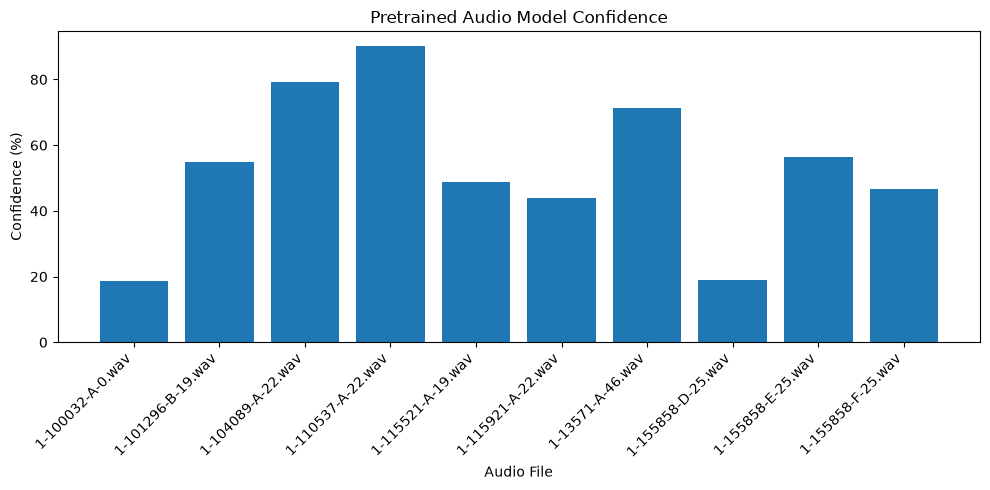

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["filename"],
    results_df["confidence"]
)

plt.xlabel("Audio File")
plt.ylabel("Confidence (%)")
plt.title("Pretrained Audio Model Confidence")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
plt.savefig(
    "../results/prediction_confidence.png",
    dpi=150,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>